In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from utils import RAT
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from utils_PI import WholeSessionDecoder

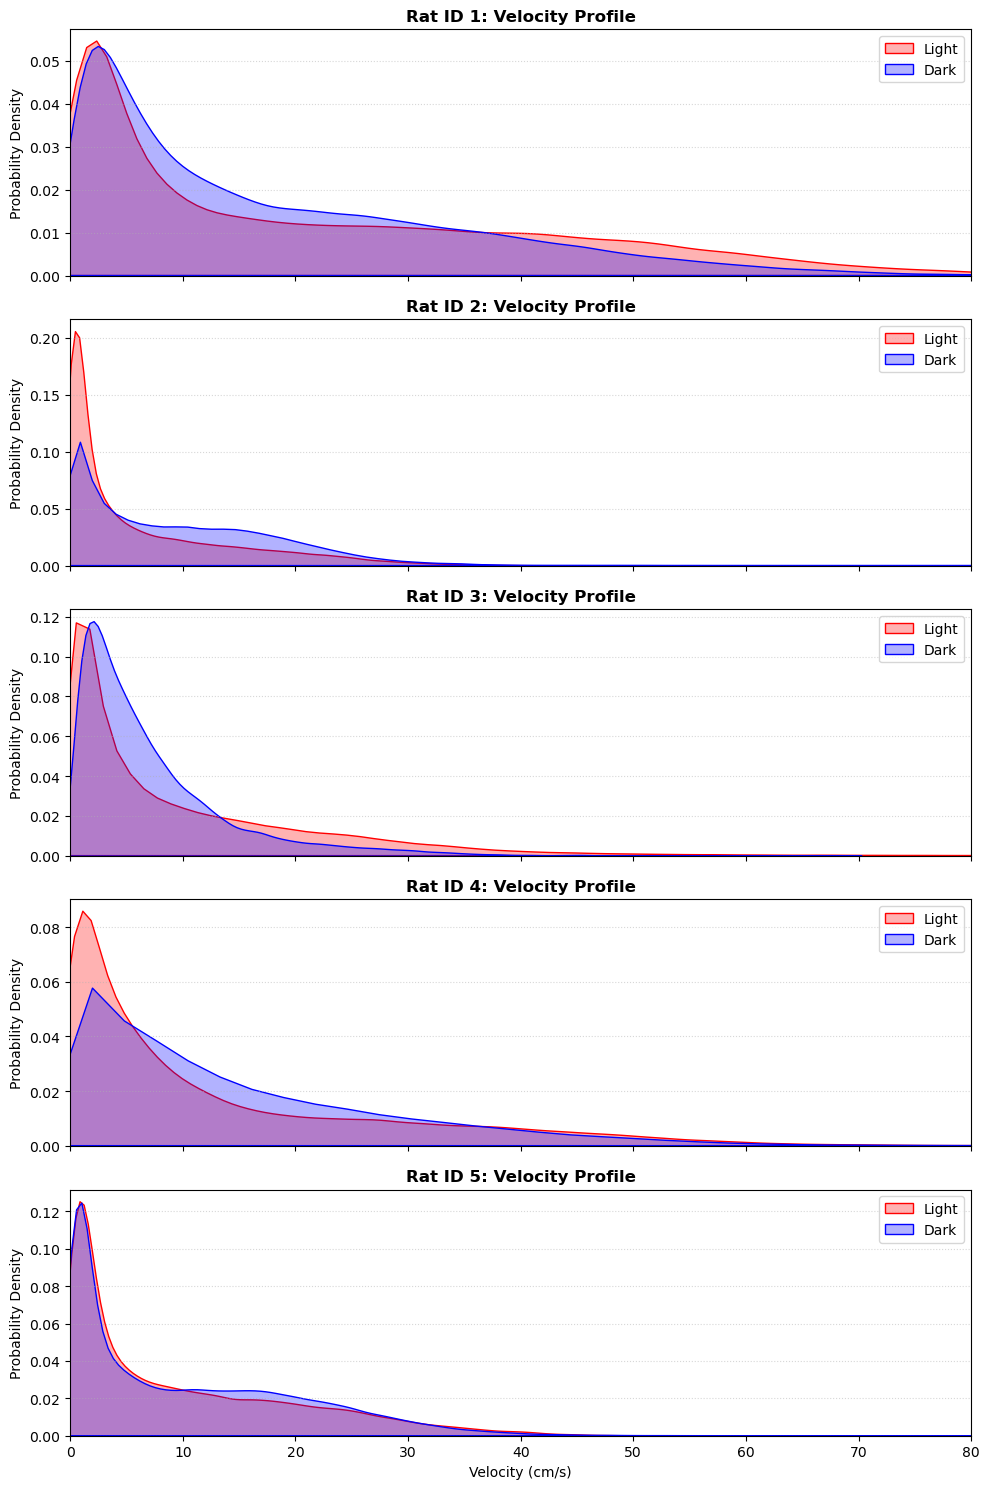

In [ ]:
def plot_rat_velocity_profiles(rat_ids):
    fig, axes = plt.subplots(len(rat_ids), 1, figsize=(10, 3 * len(rat_ids)), sharex=True)
    
    for i, rid in enumerate(rat_ids):
        # 1. Collect velocity data for both conditions
        # (Assuming your decoder objects provide the velocity array .v)
        v_light = WholeSessionDecoder(RAT_ID=rid, LIGHTING='light').v
        v_dark = WholeSessionDecoder(RAT_ID=rid, LIGHTING='dark').v
        
        # 2. Plot Kernel Density Estimates (KDE)
        sns.kdeplot(v_light, ax=axes[i], color='red', fill=True, alpha=0.3, label='Light')
        sns.kdeplot(v_dark, ax=axes[i], color='blue', fill=True, alpha=0.3, label='Dark')
        
        # 3. Aesthetics
        axes[i].set_title(f'Rat ID {rid}: Velocity Profile', fontweight='bold')
        axes[i].set_ylabel('Probability Density')
        axes[i].set_xlim(0, 80)  # Standard range for rat exploration
        axes[i].legend(loc='upper right')
        axes[i].grid(axis='y', linestyle=':', alpha=0.5)

    axes[-1].set_xlabel('Velocity (cm/s)')
    plt.tight_layout()
    plt.show()

# Execution
plot_rat_velocity_profiles([1, 2, 3, 4, 5])

In [11]:
def get_neuron_stats(rat_ids , lighting='light'):
    neuron_records = []

    for rid in rat_ids:
        # We only need to load one lighting condition to count neurons, 
        # as the physical probes (neurons) stay the same.
        rat_data = RAT(n=rid, lighting=lighting, filter_speed=False)
        
        # Counting the number of neurons in each module
        # This assumes mod1, mod2, mod3 are dictionaries or lists of spike times
        n_mod1 = len(rat_data.grid_mod1)
        n_mod2 = len(rat_data.grid_mod2)
        n_mod3 = len(rat_data.grid_mod3)
        total = n_mod1 + n_mod2 + n_mod3
        
        neuron_records.append({
            'Rat ID': rid,
            'Grid Mod 1': n_mod1,
            'Grid Mod 2': n_mod2,
            'Grid Mod 3': n_mod3,
            'Total Grid Cells': total
        })

    return pd.DataFrame(neuron_records)

# Execute
rat_list = [1, 2, 3, 4, 5]
df_neurons = get_neuron_stats(rat_list)

# Display the table
print("--- Neuron Counts per Rat and Module ---")
print(df_neurons.to_string(index=False))


# Execute
rat_list = [1, 2, 3, 4, 5]
df_neurons = get_neuron_stats(rat_list , lighting='dark')  # Lighting doesn't affect neuron count, but we specify it for clarity

# Display the table
print("--- Neuron Counts per Rat and Module ---")
print(df_neurons.to_string(index=False))

--- Neuron Counts per Rat and Module ---
 Rat ID  Grid Mod 1  Grid Mod 2  Grid Mod 3  Total Grid Cells
      1          89         118          51               258
      2          41          74          90               205
      3          40          68          78               186
      4          47          36           0                83
      5          31          44          35               110
--- Neuron Counts per Rat and Module ---
 Rat ID  Grid Mod 1  Grid Mod 2  Grid Mod 3  Total Grid Cells
      1          89         118          51               258
      2          41          74          90               205
      3          40          68          78               186
      4          47          36           0                83
      5          31          44          35               110


In [ ]:
def get_duration_stats(rat_ids):
    duration_records = []

    for rid in rat_ids:
        row = {'Rat ID': rid}
        for mode in ['light', 'dark']:
            # Load the rat data
            # We use filter_speed=True to see how much "usable" data we have for decoding
            rat_data = RAT(n=rid, lighting=mode, filter_speed=False)
            
            if len(rat_data.T) > 0:
                # Duration is the span of time covered by the filtered timestamps
                duration_seconds = rat_data.T[-1] - rat_data.T[0]
                duration_minutes = duration_seconds / 60.0
                # print(f"Rat {rid} in {mode}: Duration (min) = {duration_seconds:.2f}")
            else:
                duration_minutes = 0
            
            row[f'{mode.capitalize()} (min)'] = duration_minutes
        
        # Calculate Total Usable Time
        row['Total Active (min)'] = row['Light (min)'] + row['Dark (min)']
        duration_records.append(row)
    # print(duration_records)
    return pd.DataFrame(duration_records)

# Execute
rat_list = [1, 2, 3, 4, 5]
df_durations = get_duration_stats(rat_list)

# Display the table
print("--- Recording Durations (Active Time) ---")
pd.options.display.float_format = '{:.2f}'.format
print(df_durations.to_string(index=False))

Rat 1 in light: Duration (min) = 3621.41
Rat 1 in dark: Duration (min) = 3524.31
Rat 2 in light: Duration (min) = 1945.76
Rat 2 in dark: Duration (min) = 3218.63
Rat 3 in light: Duration (min) = 2234.92
Rat 3 in dark: Duration (min) = 3600.95
Rat 4 in light: Duration (min) = 2991.39
Rat 4 in dark: Duration (min) = 3007.54
Rat 5 in light: Duration (min) = 1367.85
Rat 5 in dark: Duration (min) = 3016.89
--- Recording Durations (Active Time) ---
 Rat ID  Light (min)  Dark (min)  Total Active (min)
      1        60.36       58.74              119.10
      2        32.43       53.64               86.07
      3        37.25       60.02               97.26
      4        49.86       50.13               99.98
      5        22.80       50.28               73.08


In [ ]:
def get_detailed_duration_stats(rat_ids):
    duration_records = []

    for rid in rat_ids:
        row = {'Rat ID': rid}
        
        for mode in ['light', 'dark']:
            # Load rat data with speed filtering enabled
            rat_data = RAT(n=rid, lighting=mode, filter_speed=True)
            
            # 1. Total Session Span (First to Last timestamp)
            if len(rat_data.T) > 1:
                total_span = (rat_data.T[-1] - rat_data.T[0]) / 60.0
                
                # 2. Cumulative Active Duration (Speed 3-100 cm/s)
                # We calculate this by finding the average time-step and multiplying by count
                # or by summing the actual diffs between timestamps
                dt_diffs = np.diff(rat_data.T)
                
                # We filter out large jumps in the diffs (e.g. gaps > 1s) 
                # to count only actual 'running' time
                active_seconds = np.sum(dt_diffs[dt_diffs < 1.0]) 
                active_minutes = active_seconds / 60.0
            else:
                total_span = 0
                active_minutes = 0
            
            row[f'{mode.capitalize()} Total Span (min)'] = total_span
            row[f'{mode.capitalize()} Active Only (min)'] = active_minutes
        
        duration_records.append(row)

    return pd.DataFrame(duration_records)

# Execute
rat_list = [1, 2, 3, 4, 5]
df_durations = get_detailed_duration_stats(rat_list)

# Display table
print("--- Session Span vs. Active Movement Time ---")
pd.options.display.float_format = '{:.2f}'.format
print(df_durations.to_string(index=False))

--- Session Span vs. Active Movement Time ---
 Rat ID  Light Total Span (min)  Light Active Only (min)  Dark Total Span (min)  Dark Active Only (min)
      1                   60.36                    48.96                  58.74                   52.13
      2                   32.43                    27.72                  53.64                   43.46
      3                   37.25                    33.71                  60.02                   59.44
      4                   49.86                    40.41                  50.13                   44.88
      5                   22.80                    22.13                  50.28                   48.37


In [12]:
import pandas as pd

def calculate_spatial_density(rat_ids, arena_dim=(150, 150)):
    density_records = []
    arena_area = arena_dim[0] * arena_dim[1] # in cm^2

    for rid in rat_ids:
        row = {'Rat ID': rid}
        for mode in ['light', 'dark']:
            # Load rat data
            rat_data = RAT(n=rid, lighting=mode, filter_speed=True )#, t_max = 1000)
            
            # Sum total spikes across all three modules
            total_spikes = 0
            for mod in [rat_data.grid_mod1, rat_data.grid_mod2, rat_data.grid_mod3]:
                # Sum the number of spikes for every neuron in the module
                for neuron_id in mod:
                    total_spikes += len(mod[neuron_id])
            
            # Density: Spikes per cm^2 of the arena
            density = total_spikes / arena_area
            row[f'{mode.capitalize()} Density (spikes/$cm^2$)'] = density
            
        density_records.append(row)

    return pd.DataFrame(density_records)

# Execute
rat_list = [1, 2, 3, 4, 5]
df_density = calculate_spatial_density(rat_list)

print("--- Spatial Signal Density (Total Spikes / Arena Area) ---")
pd.options.display.float_format = '{:.2f}'.format
print(df_density.to_string(index=False))

--- Spatial Signal Density (Total Spikes / Arena Area) ---
 Rat ID  Light Density (spikes/$cm^2$)  Dark Density (spikes/$cm^2$)
      1                          88.03                         71.28
      2                          32.82                         45.23
      3                          36.40                         51.22
      4                          23.41                         18.48
      5                          21.30                         44.36
